In [832]:
import tensorflow as tf

In [ ]:
histos={}
nb_epochs = 10

In [833]:
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()

In [834]:
training_images.shape, training_images

((60000, 28, 28),
 array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0,

In [835]:
training_images.ndim

3

In [836]:
test_images.shape

(10000, 28, 28)

In [837]:
training_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [838]:
training_labels.shape

(60000,)

In [839]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [840]:
labels = ["t-shirt/top", "trouser", "pullover", "dress", "coat", "sandals", "shirt",
         "sneaker", "bag", "ankle boot"]

In [841]:
labels[8]

'bag'

In [842]:
training_images[45]

array([[  0,   0,   0,   1,   0,   0,   0,   0,   0,  34, 148, 202, 107,
         84, 162, 198,  90,  26,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21, 107, 166, 168, 152, 204, 238,
        248, 237, 190, 142, 178, 158,  98,  17,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  55, 188, 140, 131, 121, 119, 116, 146,
        157, 132, 115, 136, 125, 140, 143, 181,  51,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 167, 134, 113, 130, 134, 140, 132, 125,
        125, 131, 135, 130, 133, 131, 115, 135, 163,   6,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  58, 148, 133, 124, 134, 128, 135, 128, 133,
        130, 133, 137, 138, 130, 124, 130, 133, 147,  82,   0,   1,   0,
          0,   0],
       [  0,   0,   0,   0,  86, 148, 158, 139, 124, 120, 131, 134, 132,
        134, 124, 134, 132, 137, 126, 137, 136, 146, 114,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 112, 141, 174, 143, 117, 134, 130, 128, 131,
        136, 134, 128, 128, 131, 106, 187, 149, 147, 143,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 134, 151, 167, 154, 114, 134, 138, 139, 135,
        135, 130, 130, 124, 129, 119, 229, 141, 145, 164,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 154, 169, 157, 109, 147, 140, 137, 137,
        136, 142, 141, 139, 129, 123, 201, 146, 138, 172,  21,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 145, 158, 171, 175, 111, 136, 145, 136, 135,
        138, 137, 143, 146, 140, 122, 184, 167, 136, 170,  58,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 151, 155, 189, 183, 120, 135, 132, 136, 135,
        133, 128, 130, 134, 120, 153, 230, 156, 135, 167,  83,   0,   0,
          0,   0],
       [  0,   0,   0,   1, 166, 151, 208, 175, 116, 142, 144, 138, 149,
        133, 131, 137, 140, 119, 126, 206, 198, 141, 166, 101,   0,   0,
          0,   0],
       [  0,   0,   0,   6, 169, 146, 237, 187, 104, 131, 136, 149, 147,
        137, 137, 137, 132, 137, 113, 166, 206, 151, 162, 126,   0,   0,
          0,   0],
       [  0,   0,   0,  20, 180, 136, 231, 214, 105, 134, 140, 139, 136,
        137, 136, 148, 134, 149, 111, 139, 255, 151, 158, 147,   0,   0,
          0,   0],
       [  0,   0,   0,  33, 184, 109, 217, 182, 105, 124, 143, 131, 135,
        137, 139, 138, 131, 142, 132,  99, 249, 162, 157, 172,   0,   0,
          0,   0],
       [  0,   0,   0,  35, 180, 112, 233, 143, 109, 133, 145, 146, 142,
        142, 139, 141, 135, 141, 152, 101, 205, 163, 154, 170,   0,   0,
          0,   0],
       [  0,   0,   0,  42, 183, 123, 217, 117, 126, 137, 140, 134, 137,
        135, 143, 141, 133, 133, 149, 107, 166, 176, 153, 169,  14,   0,
          0,   0],
       [  0,   0,   0,  48, 175, 147, 210, 101, 119, 136, 142, 137, 142,
        139, 147, 142, 146, 126, 138, 102, 131, 197, 161, 183,  32,   0,
          0,   0],
       [  0,   0,   0,  56, 165, 163, 213,  74, 126, 138, 149, 133, 133,
        132, 141, 134, 142, 132, 132, 126, 117, 193, 162, 172,  39,   0,
          0,   0],
       [  0,   0,   0,  62, 157, 165, 227,  39, 135, 138, 136, 142, 146,
        143, 136, 138, 134, 141, 134, 116,  78, 197, 171, 156,  44,   0,
          0,   0],
       [  0,   0,   0,  65, 162, 169, 245,  39, 140, 133, 133, 128, 132,
        134, 143, 145, 134, 133, 134, 128,  36, 208, 172, 151,  55,   0,
          0,   0],
       [  0,   0,   0,  72, 147, 168, 244,  25, 142, 137, 138, 133, 128,
        132, 147, 145, 135, 136, 133, 131,  26, 207, 173, 149,  67,   0,
          0,   0],
       [  0,   0,   0,  68, 153, 179, 250,  11, 135, 134, 139, 133, 136,
        140, 140, 143, 145, 140, 131, 126,  32, 207, 175, 136,  73,   0,
          0,   0],
       [  0,   0,   0,  61, 155, 180, 252,  23, 151, 132, 131, 133, 133,
        129, 135, 140, 132, 139, 132, 139,  38, 221, 174, 135,  77,   0,
          0,   0],
       [  0,   0,   0,  18, 147, 187, 18

In [843]:
training_images.min(), training_images.max()

(np.uint8(0), np.uint8(255))

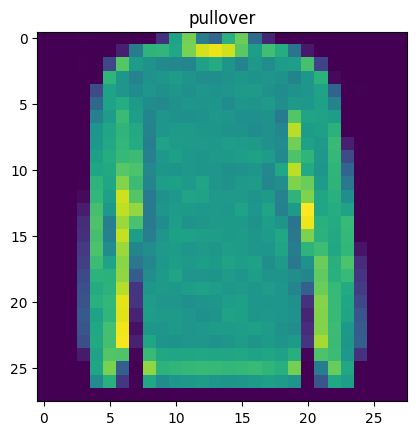

In [844]:
import matplotlib.pyplot as plt
plt.imshow(training_images[45])
plt.title(labels[training_labels[45]])
plt.show()

In [845]:
training_labels[45]

np.uint8(2)

In [846]:
labels[2]

'pullover'

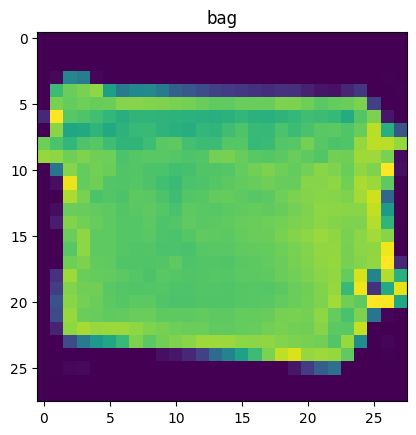

In [847]:
import matplotlib.pyplot as plt
plt.imshow(training_images[12345])
plt.title(labels[training_labels[12345]])
plt.show()

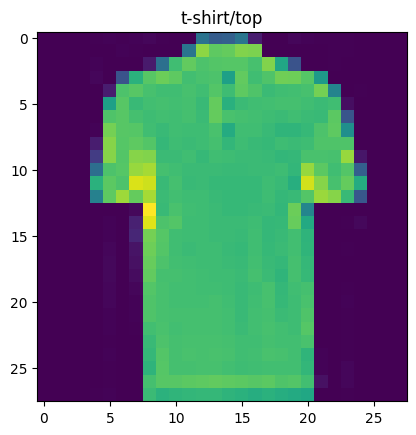

In [848]:
import matplotlib.pyplot as plt
plt.imshow(training_images[48978])
plt.title(labels[training_labels[48978]])
plt.show()

# Flatten (Applatir l'images)

In [849]:
training_images.shape

(60000, 28, 28)

In [850]:
a_training_images = training_images.reshape((60000, 28*28))
a_test_images = test_images.reshape(-1, 28*28) # -1 = toutes les images du dataset

In [851]:
a_training_images.shape, a_test_images.shape

((60000, 784), (10000, 784))

# One hot encoding

In [852]:
import numpy as np
x = np.array([1, 2, 1, 0, 3])

In [853]:
tf.keras.utils.to_categorical(x)

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [854]:
training_labels.shape

(60000,)

In [855]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [856]:
training_labels.shape

(60000, 10)

In [857]:
training_labels[45]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Softmax

In [858]:
output = [6, 3, 2]

In [859]:
6/(6+3+2) + 3/(6+3+2) + 2/(6+3+2)

1.0

In [860]:
3/(6+3+2)

0.2727272727272727

In [861]:
6/(6+3+2)

0.5454545454545454

In [862]:
2/(6+3+2)

0.18181818181818182

In [863]:
import numpy as np

In [864]:
def softmax(vect):
  r = np.exp(np.array(vect))
  return r/sum(r)

In [865]:
softmax([6, 3, 2])

array([0.93623955, 0.04661262, 0.01714783])

In [866]:
[1, 0, 0]

[1, 0, 0]

# 1er modèle de classification

In [867]:
## Normalisation des données

In [868]:
a_training_images.min(), a_training_images.max()

(np.uint8(0), np.uint8(255))

In [869]:
a_training_images = a_training_images /255.0
a_test_images = a_test_images / 255.0

In [870]:
a_training_images.min(), a_training_images.max()

(np.float64(0.0), np.float64(1.0))

In [871]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [872]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="mse", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
# model.compile(loss="mse", optimizer=SGD(learning_rate=0.01))
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.2360 - loss: 0.0895 - val_accuracy: 0.4007 - val_loss: 0.0861
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4155 - loss: 0.0850 - val_accuracy: 0.4584 - val_loss: 0.0817
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.4728 - loss: 0.0804 - val_accuracy: 0.5075 - val_loss: 0.0767
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.5228 - loss: 0.0753 - val_accuracy: 0.5382 - val_loss: 0.0716
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5756 - loss: 0.0701 - val_accuracy: 0.6185 - val_loss: 0.0667


In [873]:
histos['MSE']=h

In [874]:
type(h)
summary = {
    k: [float(x) if x != "..." else "..." for x in (v[:3] + ["..."] + v[-3:])]
    for k, v in h.history.items()
}
"3 premières et 3 dernières valeurs :", dict(summary)

('3 premières et 3 dernières valeurs :',
 {'accuracy': [0.3186500072479248,
   0.4260833263397217,
   0.4848499894142151,
   '...',
   0.4848499894142151,
   0.5399333238601685,
   0.5931333303451538],
  'loss': [0.0882042795419693,
   0.08392121642827988,
   0.07916034013032913,
   '...',
   0.07916034013032913,
   0.07400661706924438,
   0.06893550604581833],
  'val_accuracy': [0.40070000290870667,
   0.45840001106262207,
   0.5074999928474426,
   '...',
   0.5074999928474426,
   0.5382000207901001,
   0.6184999942779541],
  'val_loss': [0.08610451221466064,
   0.08168674260377884,
   0.07668628543615341,
   '...',
   0.07668628543615341,
   0.07156181335449219,
   0.06667055934667587]})

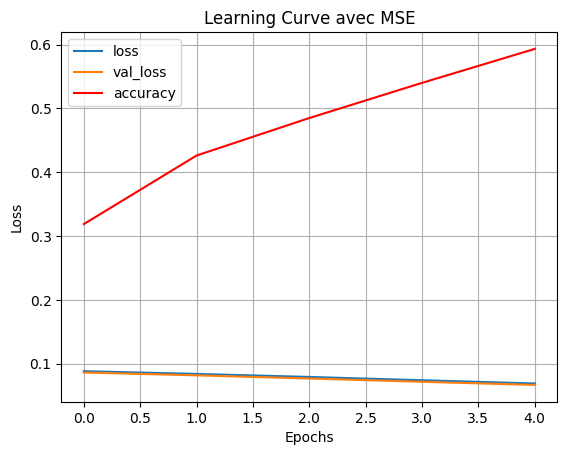

In [875]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec MSE")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

In [876]:
# accuracy: 0.5480 - loss: 0.0717 - val_accuracy: 0.5903 - val_loss: 0.0682

In [877]:
3/5

0.6

# MSE VS Cross-entropy ou Log loss

In [878]:
def mse(target, prediction):
  loss = (prediction-target) ** 2
  return loss

In [879]:
def log_loss(target, prediction):
  loss = - 1* np.log(prediction)
  return loss

In [880]:
prediction = np.arange(0, 1, 0.01)
prediction

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [881]:
target = np.ones_like(prediction)
target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [882]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

/tmp/ipython-input-4183768036.py:2: RuntimeWarning: divide by zero encountered in log
  loss = - 1* np.log(prediction)


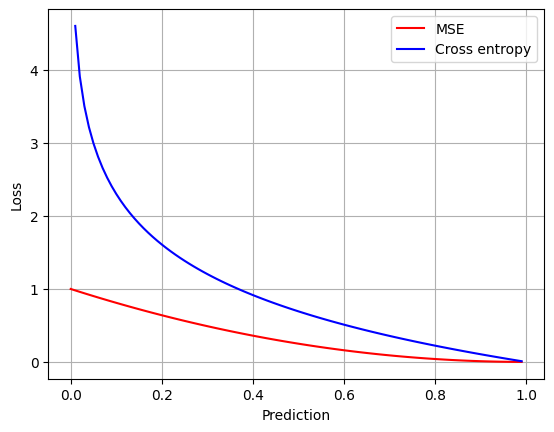

In [883]:
plt.plot(prediction, loss_mse, c='r', label='MSE')
plt.plot(prediction, loss_ce, c='b', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [884]:
def log_loss(target, prediction):
  loss = - 1* np.log(1-prediction)
  return loss

In [885]:
np.zeros_like

<function zeros_like at 0x7ab9f913b6f0>

In [886]:
target = np.zeros_like(prediction)
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [887]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

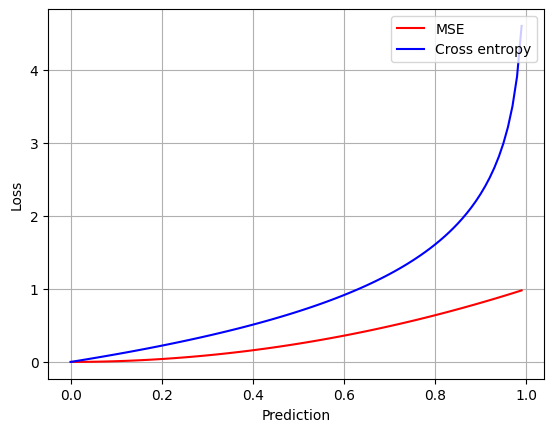

In [888]:
plt.plot(prediction, loss_mse, c='red', label='MSE')
plt.plot(prediction, loss_ce, c='blue', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# Entrainement avec cross entropy comme Loss

In [889]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.5815 - loss: 1.4841 - val_accuracy: 0.7271 - val_loss: 0.7952
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7566 - loss: 0.7307 - val_accuracy: 0.7640 - val_loss: 0.6666
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7818 - loss: 0.6289 - val_accuracy: 0.7842 - val_loss: 0.6083
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7993 - loss: 0.5809 - val_accuracy: 0.7946 - val_loss: 0.5784
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8084 - loss: 0.5499 - val_accuracy: 0.8021 - val_loss: 0.5568


In [890]:
histos['CROSS ENTROPY']=h

# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202

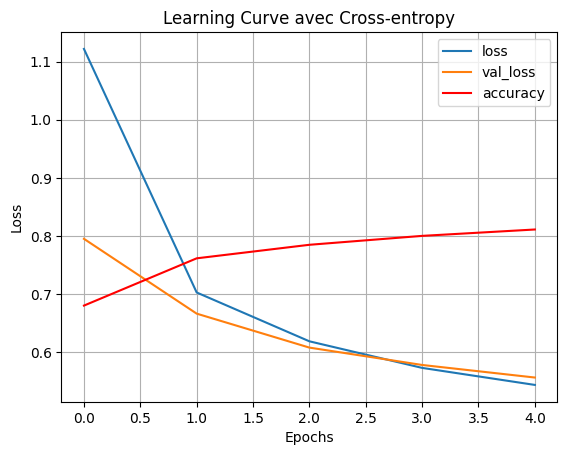

In [891]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Nouvelle fonction d'activation : Relu (REctified Linear Unit)

In [892]:
values = np.arange(-5, 5, 0.1)

In [893]:
sig = tf.nn.sigmoid(values)

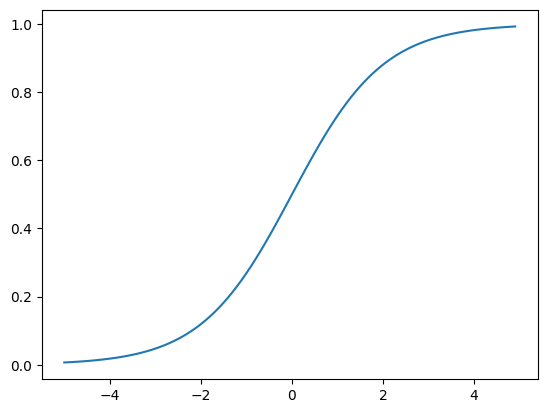

In [894]:
plt.plot(values, sig)
plt.show()

In [895]:
def relu(vect):
  return np.maximum(0, vect)

In [896]:
relu_values = relu(values)

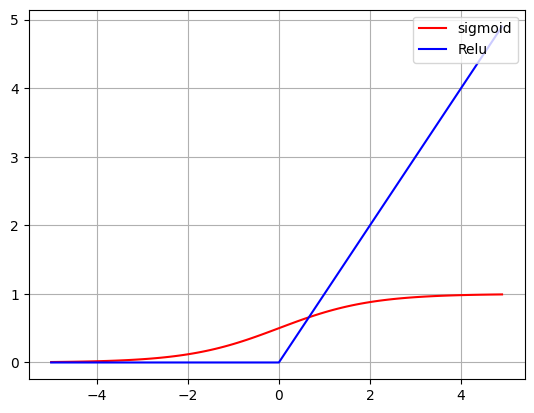

In [897]:
plt.plot(values, sig, c='r', label="sigmoid")
plt.plot(values, relu_values, c='b', label="Relu")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [898]:
model = Sequential([ Dense(units=784, activation="relu"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7141 - loss: 0.9275 - val_accuracy: 0.8100 - val_loss: 0.5493
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8290 - loss: 0.5055 - val_accuracy: 0.8328 - val_loss: 0.4898
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8428 - loss: 0.4628 - val_accuracy: 0.8376 - val_loss: 0.4617
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8496 - loss: 0.4333 - val_accuracy: 0.8457 - val_loss: 0.4420
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8549 - loss: 0.4189 - val_accuracy: 0.8495 - val_loss: 0.4339


In [899]:
histos['relu']=h
# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu          : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu          : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137

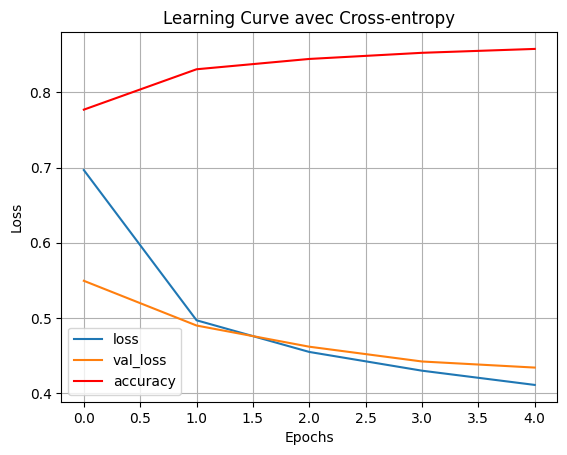

In [900]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Réseau de neurones plus complexe

In [901]:
model.summary()

Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_151 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (32, 10)               │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,292 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [902]:
model = Sequential([ Dense(units=784, activation="relu"),
                     Dense(units=128, activation="relu"),
                     Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7054 - loss: 0.9167 - val_accuracy: 0.8177 - val_loss: 0.5340
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8336 - loss: 0.4846 - val_accuracy: 0.8387 - val_loss: 0.4614
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8522 - loss: 0.4253 - val_accuracy: 0.8433 - val_loss: 0.4482
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8595 - loss: 0.4023 - val_accuracy: 0.8423 - val_loss: 0.4543
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8672 - loss: 0.3781 - val_accuracy: 0.8578 - val_loss: 0.4004


In [903]:
histos['complexe']=h
# Epoch 5/5
# MSE            : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY  : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu           : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453
# model complexe : accuracy: 0.8676 - loss: 0.3768 - val_accuracy: 0.8541 - val_loss: 0.4082

# Epoch 50/50
# MSE            : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY  : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu           : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137
# model complexe :

In [904]:
model.summary()

Model: "sequential_59"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_153 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [905]:
import matplotlib.pyplot as plt

def plot_loss_curve(history):


  plt.plot(list(range(len(history['loss']))), history['loss'], label = "loss")
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label="val_loss")
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend(loc='upper right')
  plt.show()

def plot_accuracy_curve(history):


  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper right')
  plt.show()


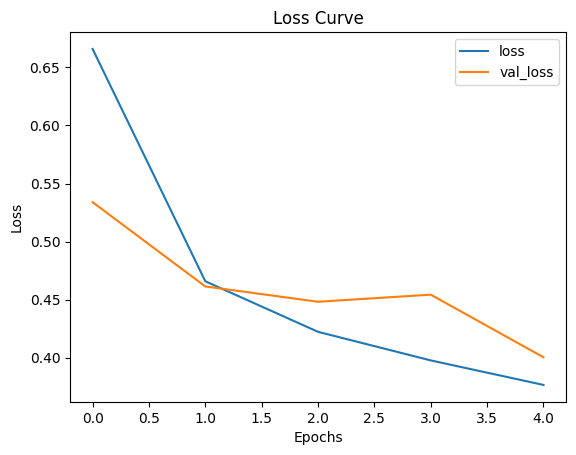

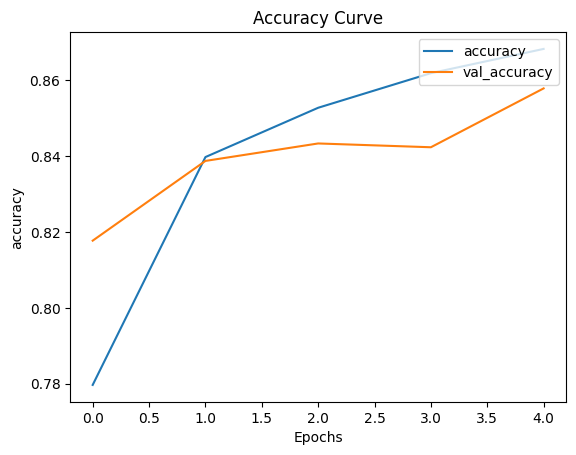

In [906]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Combattre le overfitting : Dropout

In [907]:
dropout = tf.keras.layers.Dropout(0.5, input_shape=(2,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [908]:
# ?tf.keras.layers.Dropout

In [909]:
x = np.arange(1,11).reshape(5, 2).astype(np.float32)

In [910]:
x

array([[ 1.,  2.],
       [ 3.,  4.],
       [ 5.,  6.],
       [ 7.,  8.],
       [ 9., 10.]], dtype=float32)

In [911]:
dropout(x, training=True)

<tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 2.,  4.],
       [ 6.,  0.],
       [ 0., 12.],
       [14.,  0.],
       [18., 20.]], dtype=float32)>

In [912]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))
# default: epochs=50

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.6002 - loss: 1.1284 - val_accuracy: 0.8029 - val_loss: 0.5593
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7903 - loss: 0.6042 - val_accuracy: 0.8276 - val_loss: 0.4920
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8169 - loss: 0.5254 - val_accuracy: 0.8347 - val_loss: 0.4572
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8279 - loss: 0.4910 - val_accuracy: 0.8421 - val_loss: 0.4392
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8388 - loss: 0.4533 - val_accuracy: 0.8495 - val_loss: 0.4172


In [913]:
histos['Dropout']=h

# Cf bilan en fin de doc

In [914]:
model.summary()

Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_156 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_157 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_158 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

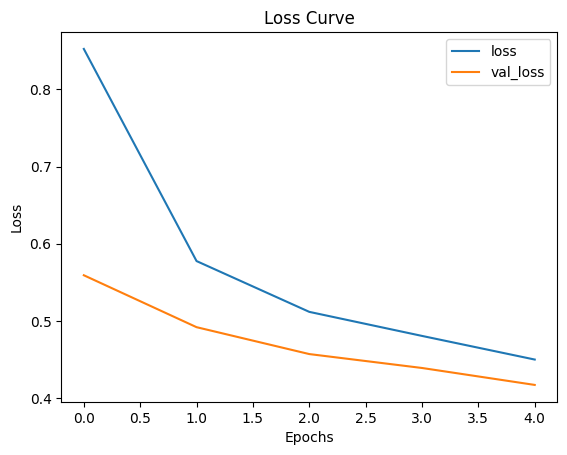

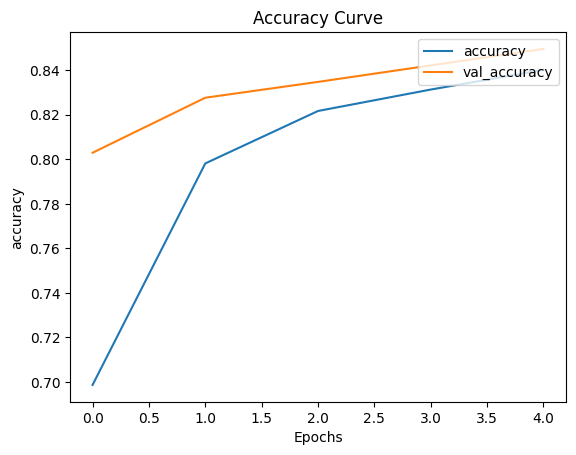

In [915]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Adam optimiser

In [916]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.9,
    beta_2=0.999)

In [917]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=adam, metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.5932 - loss: 1.1703 - val_accuracy: 0.7576 - val_loss: 0.6738
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.6572 - loss: 0.9387 - val_accuracy: 0.7593 - val_loss: 0.6755
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.6690 - loss: 0.9234 - val_accuracy: 0.7628 - val_loss: 0.6989
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.6684 - loss: 0.9309 - val_accuracy: 0.7591 - val_loss: 0.6868
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6813 - loss: 0.9070 - val_accuracy: 0.7555 - val_loss: 0.6855


In [918]:
histos['Adam'] = h

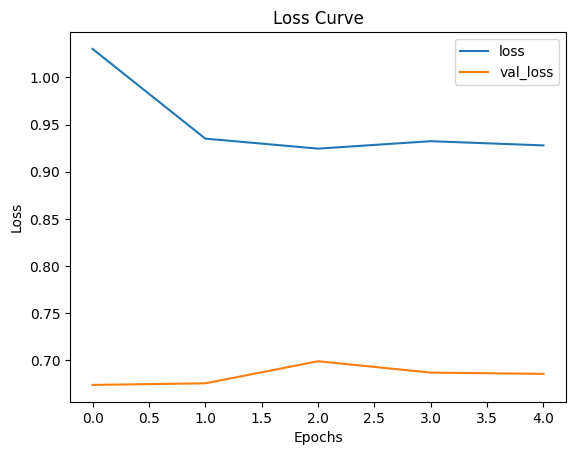

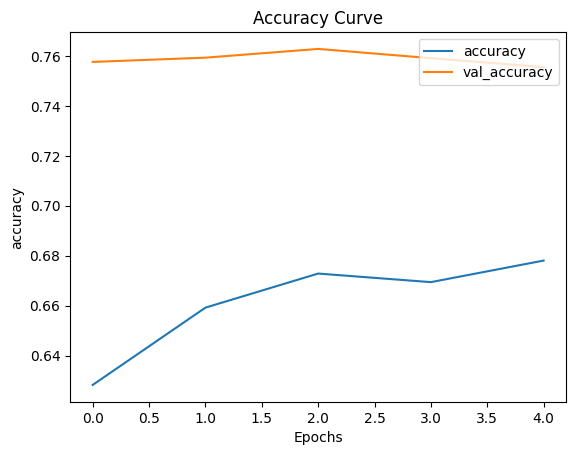

In [919]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

In [920]:
model.summary()

Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_159 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_160 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_161 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151,632 (8.21 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,434,422 (5.47 MB)

# Model Checkpoint

In [921]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [922]:
best_model = "best_model.h5"

model_ckp = ModelCheckpoint(filepath=best_model,
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)

In [923]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp])
# default: epochs=50

Epoch 1/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6022 - loss: 1.1490

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.6023 - loss: 1.1487 - val_accuracy: 0.8018 - val_loss: 0.5593
Epoch 2/5
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7902 - loss: 0.6059

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7902 - loss: 0.6058 - val_accuracy: 0.8276 - val_loss: 0.4869
Epoch 3/5
1869/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8157 - loss: 0.5256

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8157 - loss: 0.5256 - val_accuracy: 0.8351 - val_loss: 0.4570
Epoch 4/5
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8270 - loss: 0.4876

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8270 - loss: 0.4875 - val_accuracy: 0.8414 - val_loss: 0.4337
Epoch 5/5
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8390 - loss: 0.4564

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8390 - loss: 0.4564 - val_accuracy: 0.8497 - val_loss: 0.4176


In [924]:
model_save = tf.keras.models.load_model('best_model.h5')

In [925]:
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8558 - loss: 0.4085


[0.4176170527935028, 0.8496999740600586]

# Early Stopping

In [926]:
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2)

In [927]:
model_ckp

In [928]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp, stop])
# default: epochs=1000

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.5995 - loss: 1.1479 - val_accuracy: 0.8078 - val_loss: 0.5560
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7902 - loss: 0.6059 - val_accuracy: 0.8230 - val_loss: 0.4932
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8161 - loss: 0.5213 - val_accuracy: 0.8328 - val_loss: 0.4569
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8287 - loss: 0.4861 - val_accuracy: 0.8445 - val_loss: 0.4329
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8365 - loss: 0.4617 - val_accuracy: 0.8451 - val_loss: 0.4203


In [929]:
arr=np.array([
      [1,2,3],
      [4,5,6]
    ])
print(arr)
arr.ndim

# type(h)
h.history['accuracy'][-1], h.history['loss'][-1]
histos['callbacks'] = h

[[1 2 3]
 [4 5 6]]


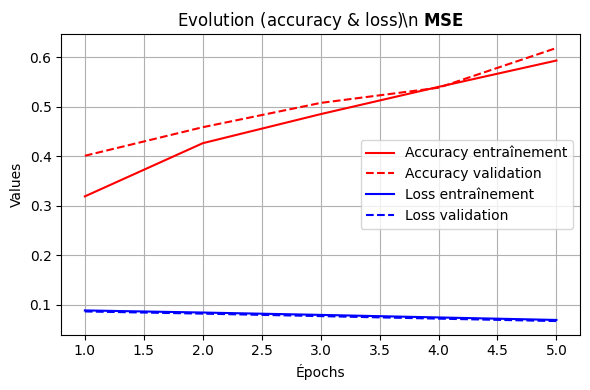

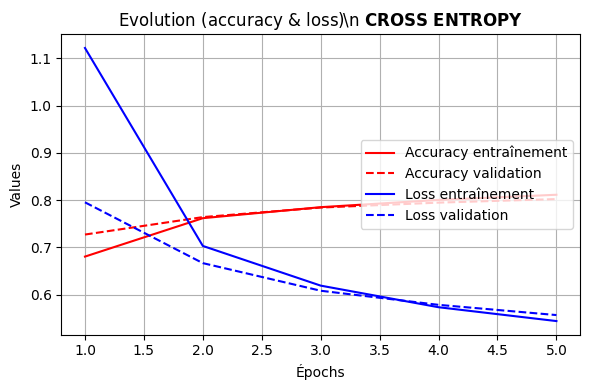

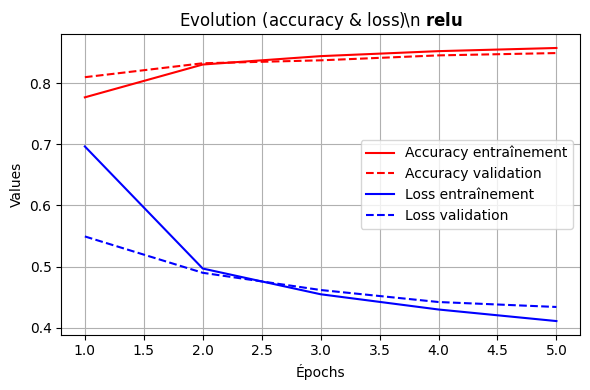

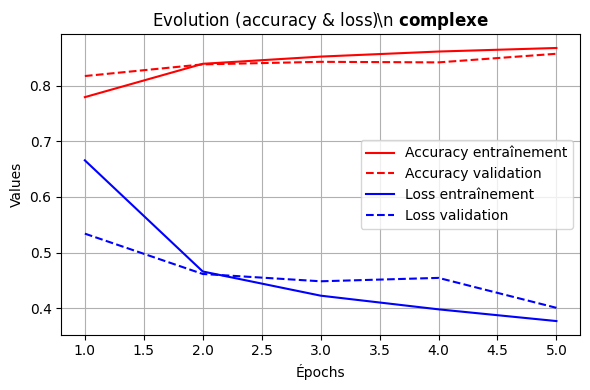

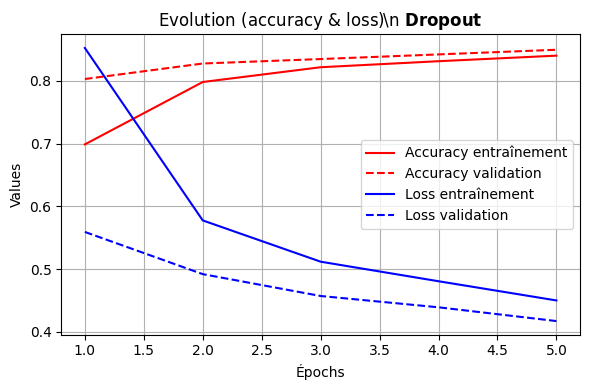

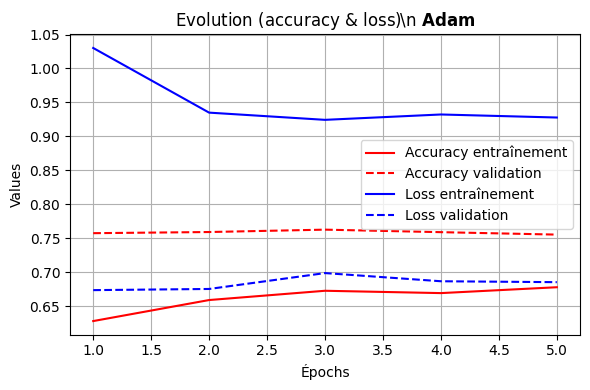

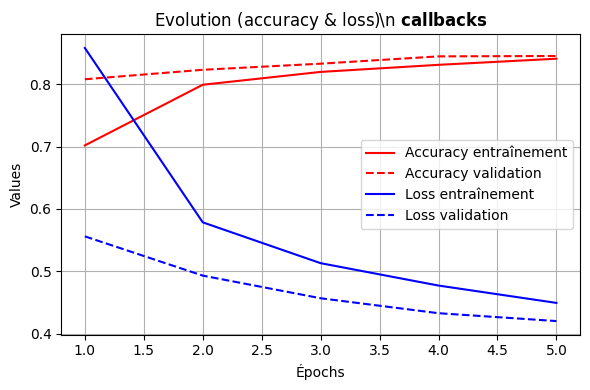

In [930]:
import matplotlib.pyplot as plt

def graph4val(history, name='ok'):

    # Récupération des métriques
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Création de la figure
    plt.figure(figsize=(6, 4))

    # Accuracy
    plt.plot(epochs, acc, 'r-', label='Accuracy entraînement')
    plt.plot(epochs, val_acc, 'r--', label='Accuracy validation')

    # Loss
    plt.plot(epochs, loss, 'b-', label='Loss entraînement')
    plt.plot(epochs, val_loss, 'b--', label='Loss validation')

    # Mise en forme
    name = name.replace(" ", r"\ ")
    plt.title(rf"Evolution (accuracy & loss)\n $\mathbf{{{name}}}$")
    plt.xlabel("Épochs")
    plt.ylabel("Values")
    plt.legend(loc="center right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



modes = ['MSE', 'CROSS ENTROPY', 'relu', 'complexe', 'Dropout', 'Adam','callbacks']
for mode in modes:
  graph4val(histos[mode], mode)

## Voici les 4 courbes clés pour suivre l’apprentissage de ton modèle : accuracy et loss sur entraînement et validation.

Tu peux maintenant visualiser clairement :

* Si ton modèle progresse (accuracy monte, loss descend),

* S’il généralise bien (val_accuracy proche de accuracy),

* Ou s’il sur-apprend (val_loss qui remonte alors que loss descend).

## 📊 Lecture des courbes

* Courbes rouges : accuracy (entraînement et validation)

* Courbes bleues : loss (entraînement et validation)

* Si les courbes de validation divergent de celles d’entraînement, c’est un signal d’overfitting.

* Si les 4 courbes convergent bien, ton modèle est stable et performant.

In [944]:
import pandas as pd

# Initialiser une liste pour stocker les résultats
results = []

for mode in modes:
    h = histos[mode].history
    results.append({
        'Méthode': mode,
        'Accuracy': h['accuracy'][-1],
        'Val Accuracy': h['val_accuracy'][-1],
        'Loss': h['loss'][-1],
        'Val Loss': h['val_loss'][-1]
    })

# Créer le DataFrame
df = pd.DataFrame(results)

In [945]:
# Pour accuracy et val_accuracy → max
best_acc = df.loc[df['Accuracy'].idxmax(), 'Méthode']
best_val_acc = df.loc[df['Val Accuracy'].idxmax(), 'Méthode']

# Pour loss et val_loss → min
best_loss = df.loc[df['Loss'].idxmin(), 'Méthode']
best_val_loss = df.loc[df['Val Loss'].idxmin(), 'Méthode']

# Résumé sous forme de tableau
summary = pd.DataFrame({
    'Métrique': ['Accuracy', 'Val Accuracy', 'Loss', 'Val Loss'],
    'Meilleure Méthode': [best_acc, best_val_acc, best_loss, best_val_loss]
})
print(summary)


       Métrique Meilleure Méthode
0      Accuracy          complexe
1  Val Accuracy          complexe
2          Loss               MSE
3      Val Loss               MSE


# Predictions

In [931]:
model_save = tf.keras.models.load_model('best_model.h5')

In [932]:
model_save.summary()

Model: "sequential_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_162 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_164 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [933]:
a_test_images[0].shape

(784,)

In [934]:
test_labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [935]:
np.argmax(test_labels[0])

np.int64(9)

In [936]:
labels[9]

'ankle boot'

In [937]:
pred = model_save.predict(a_test_images[9].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [938]:
pred

array([[2.9013572e-05, 4.1732914e-05, 6.4739329e-06, 4.7429465e-05,
        1.4454579e-05, 1.0692851e-02, 3.1913867e-05, 9.8723376e-01,
        4.6228699e-04, 1.4400568e-03]], dtype=float32)

In [939]:
np.argmax(pred)

np.int64(7)

In [940]:
labels[7]

'sneaker'

In [941]:
pred = model.predict(a_test_images[9].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


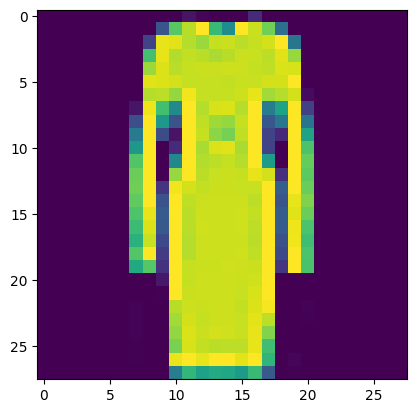

In [942]:
import matplotlib.pyplot as plt
plt.imshow(training_images[2500])
# plt.title(labels[training_labels[45]])
plt.show()

In [943]:
# (60000, 784) (1, 784)

## Epoch 5/5

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.5523   | 0.0708 | 0.5839       | 0.0674   |
| CROSS ENTROPY | 0.8085   | 0.5455 | 0.8037       | 0.5520   |
| relu          | 0.8570   | 0.4169 | 0.8406       | 0.4453   |
| model complexe| 0.8676   | 0.3768 | 0.8541       | 0.4082   |
| Dropout       | 0.8405   | 0.4501 | 0.8492       | 0.4157   |
| Adam          | 0.6805   | 0.8744 | 0.7445       | 0.6483   |
| Callbacks     | 0.8400   | 0.4521 | 0.8515       | 0.4164   |

## Epoch 50/50

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.7930   | 0.0310 | 0.7834       | 0.0319   |
| CROSS ENTROPY | 0.8674   | 0.3769 | 0.8482       | 0.4202   |
| relu          | 0.9247   | 0.2136 | 0.8892       | 0.3137   |
| model complexe| 0.9536   | 0.1322 | 0.8966       | 0.3154   |
| Dropout       | 0.9107   | 0.2454 | 0.8954       | 0.3021   |
| Adam          | 0.6543   | 0.9675 | 0.7221       | 0.7787   |
| Callbacks     | 0.8815   | 0.3273 | 0.8764       | 0.3416   |

(Callbacks s'est arrêté à 20/50)